<a href="https://colab.research.google.com/github/Jessica1842553/MCDpycd2026/blob/main/T4_PCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tarea 4 - Procesamiento de imágenes con `opencv`  
Jessica Lizeth Hernández Bracho - 1842553

### 1. Carga y Visualización

In [42]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

Imagen cargada con éxito. Dimensiones: 900px de alto x 900px de ancho, 3 canales de color.


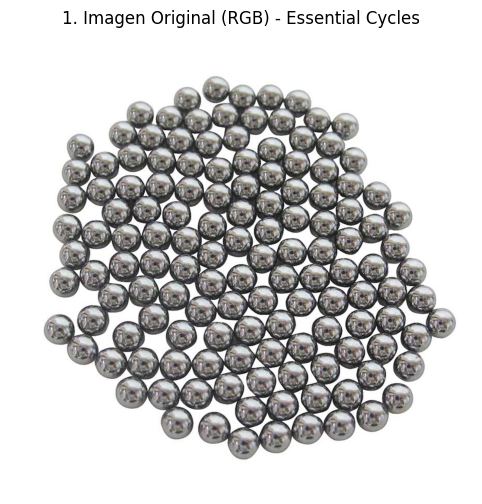

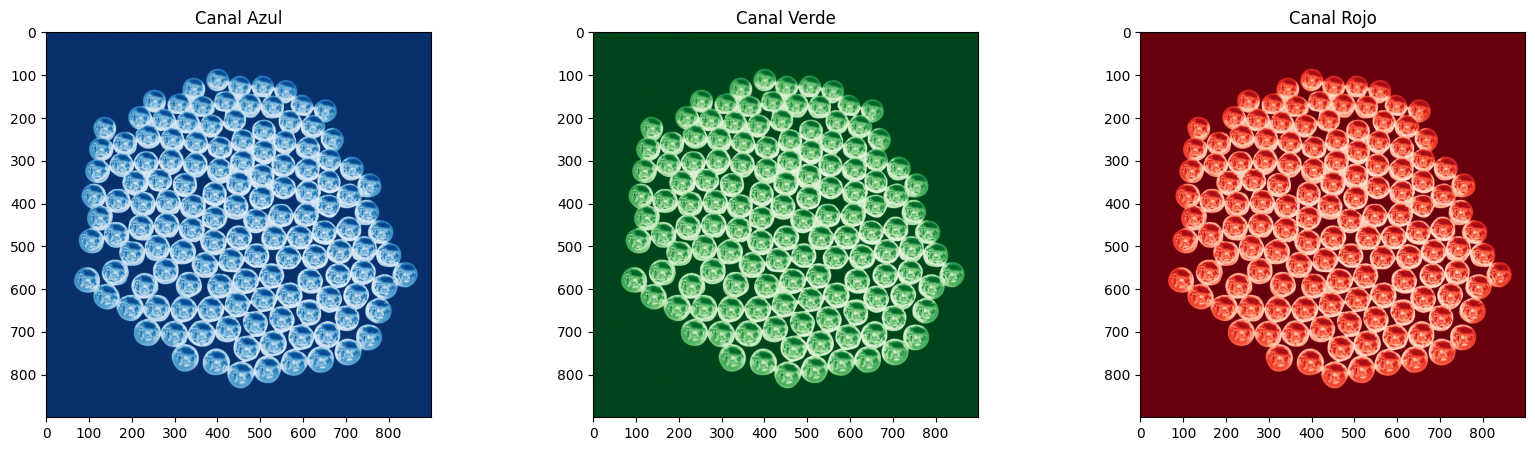

In [43]:
# 1. Carga de imagen
img = cv2.imread('T4.Ball.jpg')
# url: https://www.essentialcycles.com/cdn/shop/files/090705-01_1.jpg?v=1737387525

if img is None:
    print("Error: No se encontró el archivo.")
else:
    # Obtener dimensiones
    h, w, ch = img.shape
    print(f"Imagen cargada con éxito. Dimensiones: {h}px de alto x {w}px de ancho, {ch} canales de color.")

    # Convertir BGR a RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Mostrar la imagen original
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title('1. Imagen Original (RGB) - Essential Cycles')
    plt.axis('off')
    plt.show()

    # Separar los canales de color
    B, G, R = cv2.split(img)

    # Visualizar los canales individuales
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    axes[0].imshow(B, cmap='Blues')
    axes[0].set_title('Canal Azul')
    axes[1].imshow(G, cmap='Greens')
    axes[1].set_title('Canal Verde')
    axes[2].imshow(R, cmap='Reds')
    axes[2].set_title('Canal Rojo')
    plt.show()

### 2. Escala de Grises, Binarización y Transformaciones

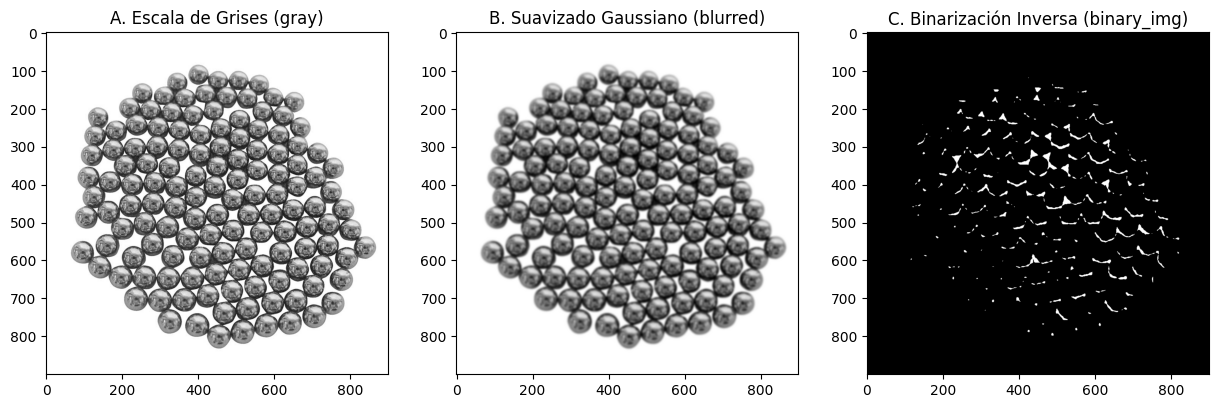

In [44]:
# Escala de grises
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Suavizado Gaussiano
blurred = cv2.GaussianBlur(gray, (13, 13), 0)

# Binarización
# Umbral para aislar los balines oscuros
_, binary_img = cv2.threshold(blurred, 60, 255, cv2.THRESH_BINARY_INV)

# Resultados intermedios
plt.figure(figsize=(15, 6))
plt.subplot(131)
plt.imshow(gray, cmap='gray')
plt.title('A. Escala de Grises (gray)')
plt.subplot(132)
plt.imshow(blurred, cmap='gray')
plt.title('B. Suavizado Gaussiano (blurred)')
plt.subplot(133)
plt.imshow(binary_img, cmap='gray')
plt.title('C. Binarización Inversa (binary_img)')
plt.show()

### 3. Detección de Bordes (Canny) y Detección de Círculos (Hough)

BITÁCORA DE INSPECCIÓN
Total de 134 balines en la muestra.

Balín #1 -> Centroide: (X: 759, Y: 361) | Radio: 24 px
Balín #2 -> Centroide: (X: 392, Y: 489) | Radio: 23 px
Balín #3 -> Centroide: (X: 687, Y: 512) | Radio: 23 px
Balín #4 -> Centroide: (X: 657, Y: 706) | Radio: 24 px
Balín #5 -> Centroide: (X: 568, Y: 615) | Radio: 24 px
Balín #6 -> Centroide: (X: 389, Y: 373) | Radio: 23 px
Balín #7 -> Centroide: (X: 451, Y: 352) | Radio: 23 px
Balín #8 -> Centroide: (X: 322, Y: 647) | Radio: 24 px
Balín #9 -> Centroide: (X: 706, Y: 455) | Radio: 24 px
Balín #10 -> Centroide: (X: 655, Y: 185) | Radio: 24 px
Balín #11 -> Centroide: (X: 628, Y: 524) | Radio: 23 px
Balín #12 -> Centroide: (X: 230, Y: 593) | Radio: 24 px
Balín #13 -> Centroide: (X: 551, Y: 424) | Radio: 24 px
Balín #14 -> Centroide: (X: 712, Y: 322) | Radio: 24 px
Balín #15 -> Centroide: (X: 806, Y: 518) | Radio: 24 px
Balín #16 -> Centroide: (X: 334, Y: 590) | Radio: 23 px
Balín #17 -> Centroide: (X: 532, Y: 478) | Radio: 23 

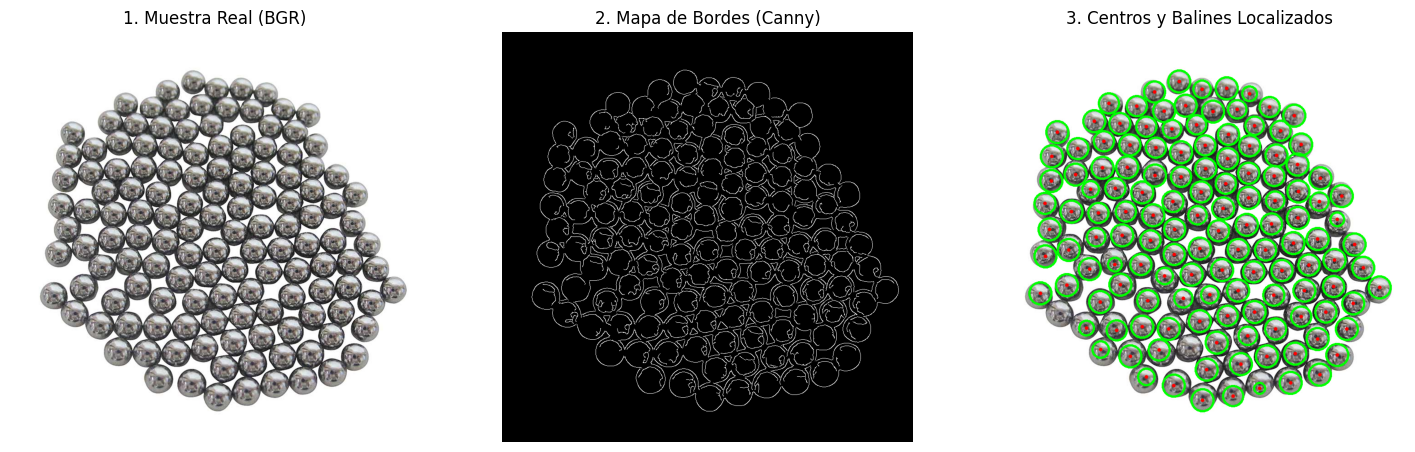

In [45]:
# Detección de bordes
edges = cv2.Canny(blurred, 30, 150)

# Transformada de Hough para Círculos (HoughCircles)
img_resultados = img.copy()

circles = cv2.HoughCircles(
    blurred,
    cv2.HOUGH_GRADIENT,
    dp=1.2,          # Resolución del acumulador
    minDist=35,      # Distancia mínima entre los centros de los balines
    param1=50,       # Detección de bordes (50, 100, 150)
    param2=25,       # Umbral de validación de forma circular (20, 30, 40)
    minRadius=10,    # Radio mínimo
    maxRadius=25     # Radio máximo
)

# Convertir BGR a RGB
img_resultados_rgb = cv2.cvtColor(img_resultados, cv2.COLOR_BGR2RGB)

print("BITÁCORA DE INSPECCIÓN")
if circles is not None:
    # Redondear y convertir a uint16
    circles = np.uint16(np.around(circles))

    total_balines = circles.shape[1]
    print(f"Total de {total_balines} balines en la muestra.\n")

    for idx, i in enumerate(circles[0, :]):
        #i[0] = Centro en X, i[1] = Centro en Y, i[2] = Radio estimado en píxeles
        print(f"Balín #{idx+1} -> Centroide: (X: {i[0]}, Y: {i[1]}) | Radio: {i[2]} px")

        # Contorno exterior calculado en verde
        cv2.circle(img_resultados_rgb, (i[0], i[1]), i[2], (0, 255, 0), 3)
        # Centro geométrico con un punto rojo
        cv2.circle(img_resultados_rgb, (i[0], i[1]), 4, (255, 0, 0), -1)
else:
    print("No se encontraron estructuras que coincidan.")

# Visualización final
plt.figure(figsize=(18, 6))
plt.subplot(131)
plt.imshow(img_rgb)
plt.title('1. Muestra Real (BGR)')
plt.axis('off')
plt.subplot(132)
plt.imshow(edges, cmap='gray')
plt.title('2. Mapa de Bordes (Canny)')
plt.axis('off')
plt.subplot(133)
plt.imshow(img_resultados_rgb)
plt.title('3. Centros y Balines Localizados')
plt.axis('off')
plt.show()